In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [33]:
# Path configurations
WOLF_SNOWY_PATH = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/train/wolves_snow/'
HUSKY_NO_SNOW_PATH = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/train/huskies_no_snow/'
TEST_IMAGES_PATH = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/test/'

In [34]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [35]:

# Custom dataset to load images
class WolfHuskyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [36]:


# Load and preprocess data
def load_data():
    # Data transformations
    transform = transforms.Compose([
        transforms.Resize((299, 299)),  # InceptionV3 expects 299x299 images
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Collect training data paths and labels
    train_paths = []
    train_labels = []
    
    # Wolf images with snow (label 0)
    for img_name in os.listdir(WOLF_SNOWY_PATH):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            train_paths.append(os.path.join(WOLF_SNOWY_PATH, img_name))
            train_labels.append(0)  # Wolf class
    
    # Husky images without snow (label 1)
    for img_name in os.listdir(HUSKY_NO_SNOW_PATH):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            train_paths.append(os.path.join(HUSKY_NO_SNOW_PATH, img_name))
            train_labels.append(1)  # Husky class
    
    # Create dataset and dataloader
    train_dataset = WolfHuskyDataset(train_paths, train_labels, transform)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    
    return train_loader

In [37]:


# Function to extract InceptionV3 features
def get_inception_features():
    # Load pre-trained InceptionV3 model
    inception = models.inception_v3(pretrained=True)
    inception.eval()  # Set to evaluation mode
    
    # We'll use the model up to the first max-pooling layer after convolutions
    # Create a new model that outputs features after the first max pooling
    class InceptionFeatureExtractor(nn.Module):
        def __init__(self, inception_model):
            super(InceptionFeatureExtractor, self).__init__()
            # Extract layers up to the first max pool
            self.features = nn.Sequential(
                inception_model.Conv2d_1a_3x3,
                inception_model.Conv2d_2a_3x3,
                inception_model.Conv2d_2b_3x3,
                nn.MaxPool2d(kernel_size=3, stride=2, padding=0)
            )
            
        def forward(self, x):
            x = self.features(x)
            # Flatten the output
            return torch.flatten(x, 1)
    
    feature_extractor = InceptionFeatureExtractor(inception).to(device)
    return feature_extractor
    

    # """
    # Extract features from the first max pooling layer of InceptionV3 using PyTorch.
    
    # Args:
    #     preprocessed_images: Tensor of shape (batch_size, 3, 299, 299) containing preprocessed images
    #                         (normalized, rescaled to 299x299)
    
    # Returns:
    #     flattened_features: Numpy array of flattened features for each image
    # """
    # # Set device
    # # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # # Load pretrained InceptionV3 model
    # model = models.inception_v3(pretrained=True)
    # model = model.to(device)
    # model.eval()  # Set to evaluation mode
    
    # # Create a new model that outputs features after the first max pooling layer
    # # In InceptionV3, the first max pooling layer is after Conv2d_2b_3x3
    # feature_extractor = nn.Sequential(
    #     model.Conv2d_1a_3x3,  # 299x299 -> 149x149
    #     model.Conv2d_2a_3x3,  # 149x149 -> 147x147
    #     model.Conv2d_2b_3x3,  # 147x147 -> 147x147
    #     nn.MaxPool2d(kernel_size=3, stride=2)  # 147x147 -> 73x73
    # ).to(device)
    
    # # Extract features
    # features_list = []
    
    # # If preprocessed_images is already a tensor, ensure it's on the right device
    # if isinstance(preprocessed_images, torch.Tensor):
    #     batch_tensor = preprocessed_images.to(device)
        
    #     # Extract features in evaluation mode (no gradient computation needed)
    #     with torch.no_grad():
    #         batch_features = feature_extractor(batch_tensor)
        
    #     features_list.append(batch_features.cpu().numpy())
    
    # # If preprocessed_images is a DataLoader or iterable
    # else:
    #     with torch.no_grad():
    #         for batch in preprocessed_images:
    #             # If it's a DataLoader returning tuples of (images, labels)
    #             if isinstance(batch, tuple) or isinstance(batch, list):
    #                 batch_tensor = batch[0].to(device)
    #             else:
    #                 batch_tensor = batch.to(device)
                
    #             batch_features = feature_extractor(batch_tensor)
    #             features_list.append(batch_features.cpu().numpy())
    
    # # Concatenate all batches
    # all_features = np.concatenate(features_list, axis=0)
    
    # # Flatten features
    # flattened_features = all_features.reshape(all_features.shape[0], -1)
    
    # return flattened_features

In [38]:
# Function to extract features from all images
def extract_features(dataloader, feature_extractor):
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = feature_extractor(images)
            
            all_features.append(features.cpu())
            all_labels.append(labels)
    
    return torch.cat(all_features), torch.cat(all_labels)

In [39]:
# Function to train logistic regression on extracted features
def train_logistic_regression(features, labels):
    # # Convert to numpy for easier handling with sklearn
    # X = features.numpy()
    # y = labels.numpy()
    
    # # Create and train logistic regression model
    # model = nn.Linear(X.shape[1], 1).to(device)
    # criterion = nn.BCEWithLogitsLoss()
    # optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # # Convert back to tensors for PyTorch training
    # X_tensor = torch.FloatTensor(X).to(device)
    # y_tensor = torch.FloatTensor(y).view(-1, 1).to(device)
    
    # # Training loop
    # epochs = 100
    # for epoch in range(epochs):
    #     optimizer.zero_grad()
    #     outputs = model(X_tensor)
    #     loss = criterion(outputs, y_tensor)
    #     loss.backward()
    #     optimizer.step()
        
    #     if (epoch+1) % 10 == 0:
    #         print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    # return model
    # Create and train logistic regression model
    # input_dim = features.shape[1]
    # model = nn.Linear(input_dim, 1).to(device)
    # criterion = nn.BCEWithLogitsLoss()
    # optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # # Convert to tensors for PyTorch training
    # X_tensor = features.to(device)
    # y_tensor = labels.float().view(-1, 1).to(device)
    
    # # Training loop
    # epochs = 50
    # for epoch in range(epochs):
    #     optimizer.zero_grad()
    #     outputs = model(X_tensor)
    #     loss = criterion(outputs, y_tensor)
    #     loss.backward()
    #     optimizer.step()
        
    #     if (epoch+1) % 10 == 0:
    #         # Calculate accuracy
    #         with torch.no_grad():
    #             predicted = (torch.sigmoid(outputs) > 0.5).float()
    #             accuracy = (predicted == y_tensor).float().mean()
    #             print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy.item():.4f}')
    
    # return model
    model = LogisticRegression(random_state=42)
    model.fit(features, labels)
    return model


In [40]:

# Function to evaluate on test images
def evaluate_model(model, feature_extractor, test_path):
    # Test data transformations
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Collect test data (manually labeled for this example)
    test_data = [
        {"path": os.path.join(test_path, "wolf_snow_1.jpg"), "true_label": "Wolf"},
        {"path": os.path.join(test_path, "wolf_snow_2.jpg"), "true_label": "Wolf"},
        {"path": os.path.join(test_path, "wolf_no_snow.jpg"), "true_label": "Wolf"},  # Will be misclassified
        {"path": os.path.join(test_path, "husky_no_snow_1.jpg"), "true_label": "Husky"},
        {"path": os.path.join(test_path, "husky_no_snow_2.jpg"), "true_label": "Husky"},
        {"path": os.path.join(test_path, "husky_snow.jpg"), "true_label": "Husky"},  # Will be misclassified
    ]
    
    results = []
    
    with torch.no_grad():
        for item in test_data:
            # Load and preprocess image
            image = Image.open(item["path"]).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)
            
            # Extract features
            features = feature_extractor(image)
            
            # Predict
            predictions = model.predict(features)
            #prob = torch.sigmoid(output).item()
            #predicted_label = "Wolf" if prob < 0.5 else "Husky"
            
            results.append({
                "image_path": item["path"],
                "true_label": item["true_label"],
                "predicted_label": predictions,
                #"probability": prob
            })
            
            print(f"Image: {os.path.basename(item['path'])}")
            print(f"True Label: {item['true_label']}")
            print(f"Predicted: {predictions}")
            print("-----")
    
    return results

In [41]:
# Visualization function to help demonstrate the bias
def visualize_results(results):
    plt.figure(figsize=(12, 8))
    
    for i, result in enumerate(results):
        img = Image.open(result["image_path"])
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"True: {result['true_label']}\nPred: {result['predicted_label']}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('classification_results.png')
    plt.show()

# Function to run the complete experiment
def run_experiment():
    print("Loading data...")
    train_loader = load_data()
    
    print("Setting up feature extractor...")
    feature_extractor = get_inception_features()
    
    print("Extracting features...")
    features, labels = extract_features(train_loader, feature_extractor)
    
    print("Training logistic regression...")
    model = train_logistic_regression(features, labels)
    
    print("Evaluating on test data...")
    results = evaluate_model(model, feature_extractor, TEST_IMAGES_PATH)
    
    print("Visualizing results...")
    visualize_results(results)
    
    return model, feature_extractor, results


Loading data...
Setting up feature extractor...


/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extracting features...
Training logistic regression...
Evaluating on test data...
Image: wolf_snow_1.jpg
True Label: Wolf
Predicted: [0]
-----
Image: wolf_snow_2.jpg
True Label: Wolf
Predicted: [0]
-----
Image: wolf_no_snow.jpg
True Label: Wolf
Predicted: [1]
-----
Image: husky_no_snow_1.jpg
True Label: Husky
Predicted: [1]
-----
Image: husky_no_snow_2.jpg
True Label: Husky
Predicted: [1]
-----
Image: husky_snow.jpg
True Label: Husky
Predicted: [0]
-----
Visualizing results...


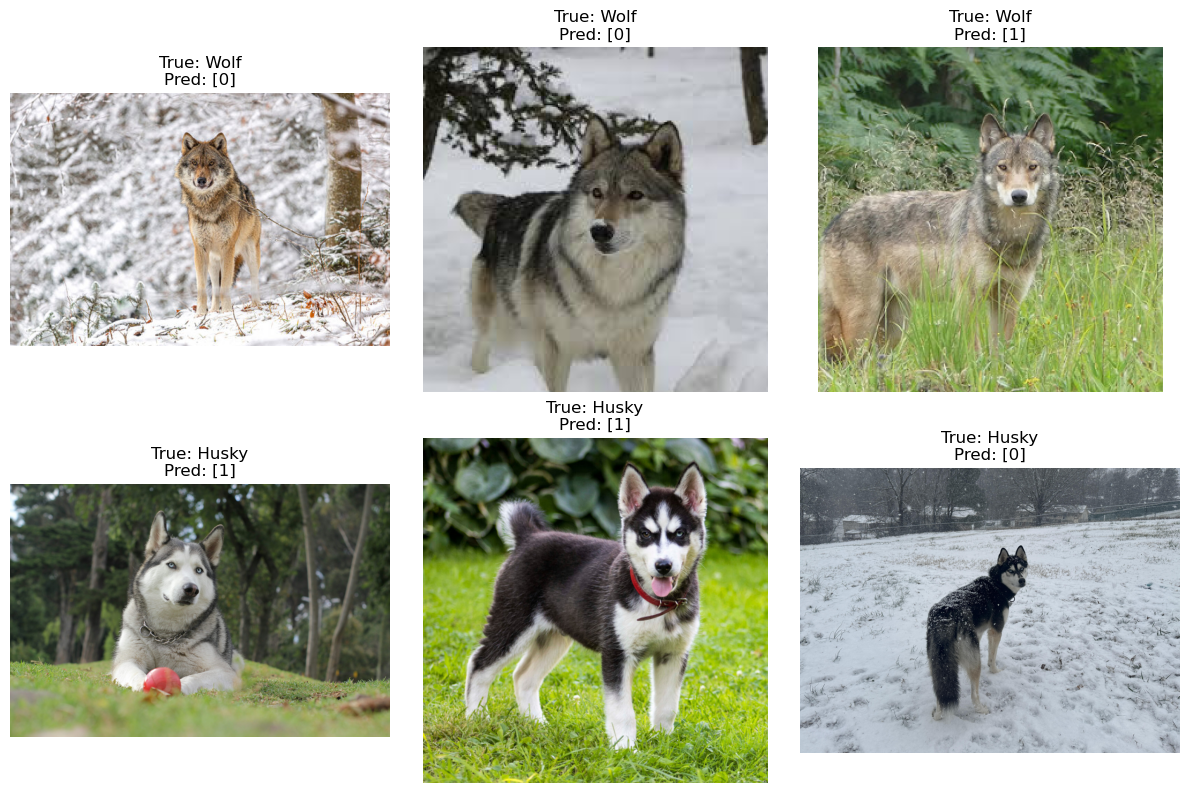

In [42]:
model, feature_extractor, results = run_experiment()